# Solar Storm Forecast — Exploratory Data Analysis

This notebook explores both datasets:
- **SDOBenchmark** images (ZIP / extracted directory)
- **OMNI2** hourly time-series (single CSV)

and characterises missing data, channel distributions, target-variable histograms,
and OMNI2 feature correlations.

In [1]:
import sys
from pathlib import Path

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

cwd = Path.cwd().resolve()
repo_root = next((path for path in [cwd, *cwd.parents] if (path / 'solar_storm_forecast').is_dir()), None)
if repo_root is None:
    raise RuntimeError("Could not locate the repository root containing 'solar_storm_forecast'.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from solar_storm_forecast.config import Config
from solar_storm_forecast.dataset import ensure_sdo_extracted, _sample_dir, _discover_timesteps

cfg = Config()
sdo_root = ensure_sdo_extracted(cfg)
print('Repository root:', repo_root)
print('SDO root:', sdo_root)
print('OMNI CSV:', cfg.omni_csv_path)

2026-03-22 14:20:21 [INFO] solar_storm_forecast.dataset: SDO data already extracted at /home/OMNIProjectwithImages/SDOBenchmark-data-full


Repository root: /home/OMNIProjectwithImages
SDO root: /home/OMNIProjectwithImages/SDOBenchmark-data-full
OMNI CSV: /home/OMNIProjectwithImages/omni2_full_dataset.csv


## 1. Training / Test Label Overview

In [2]:
import os
train_meta_path = os.path.join(sdo_root, 'training', 'meta_data.csv')
test_meta_path  = os.path.join(sdo_root, 'test', 'meta_data.csv')

train_df = pd.read_csv(train_meta_path)
test_df  = pd.read_csv(test_meta_path)

print(f'Training samples: {len(train_df)}')
print(f'Test samples:     {len(test_df)}')
print()
print('Columns:', list(train_df.columns))
train_df.head()

Training samples: 8336
Test samples:     886

Columns: ['id', 'start', 'end', 'peak_flux']


,id,start,end,peak_flux
0,11390_2012_01_05_17_06_01_0,2012-01-05 05:06:01.000000000,2012-01-05 17:06:01.000000000,8.000000e-07
1,11390_2012_01_05_17_19_01_0,2012-01-05 05:19:01.000000000,2012-01-05 17:19:01.000000000,1.647059e-06
2,11390_2012_01_05_17_19_01_1,2012-01-06 05:19:00.000000000,2012-01-06 17:19:00.000000000,1.647059e-06
3,11390_2012_01_06_17_20_58_0,2012-01-06 05:20:58.000000000,2012-01-06 17:20:58.000000000,1.164706e-06
4,11390_2012_01_04_07_22_01_0,2012-01-03 19:22:01.000000000,2012-01-04 07:22:01.000000000,2.235294e-06


## 2. Peak-Flux Distribution

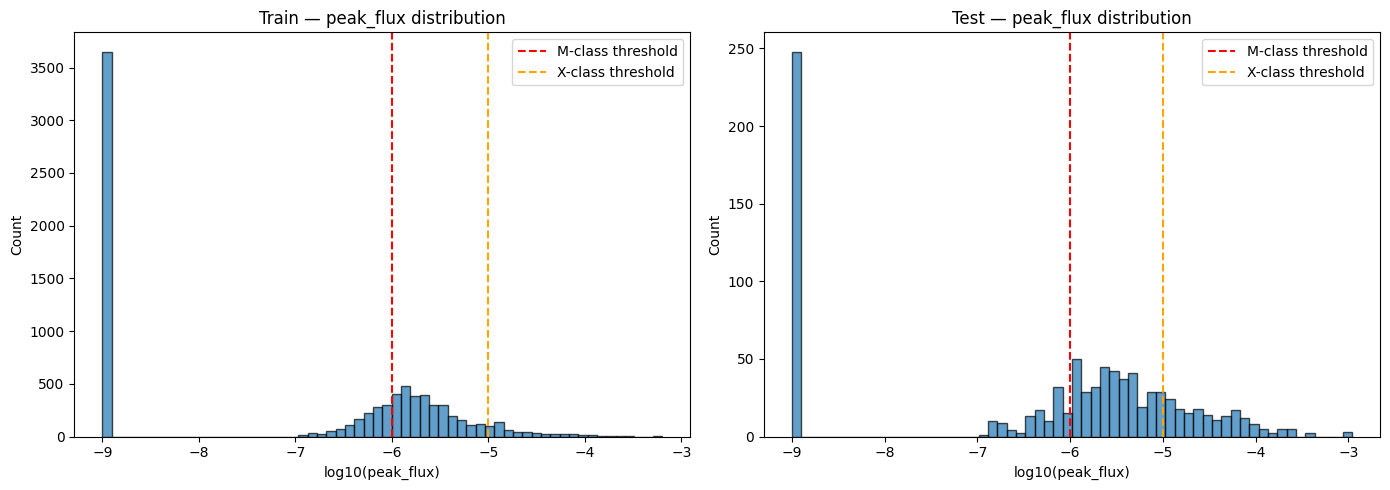

Train: quiet/C=4931  M=2891  X=514
Test: quiet/C=359  M=351  X=176


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [train_df, test_df], ['Train', 'Test']):
    log_flux = np.log10(df['peak_flux'].clip(lower=1e-12))
    ax.hist(log_flux, bins=60, edgecolor='black', alpha=0.7)
    ax.axvline(np.log10(1e-6), color='red', ls='--', label='M-class threshold')
    ax.axvline(np.log10(1e-5), color='orange', ls='--', label='X-class threshold')
    ax.set_xlabel('log10(peak_flux)')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} — peak_flux distribution')
    ax.legend()

plt.tight_layout()
plt.show()

# Class balance summary
for label, df in [('Train', train_df), ('Test', test_df)]:
    n_quiet = (df['peak_flux'] < 1e-6).sum()
    n_m     = ((df['peak_flux'] >= 1e-6) & (df['peak_flux'] < 1e-5)).sum()
    n_x     = (df['peak_flux'] >= 1e-5).sum()
    print(f'{label}: quiet/C={n_quiet}  M={n_m}  X={n_x}')

## 3. Missing-Image Analysis

For each training sample we discover the on-disk timestamps and check
whether the 5 selected channels are present at each time-step.

In [3]:
channels = cfg.selected_channels
train_split_root = os.path.join(sdo_root, 'training')

missing_counts = {ch: 0 for ch in channels}
total_slots = 0
samples_found = 0

for _, row in train_df.iterrows():
    sid = str(row['id'])
    sdir = _sample_dir(train_split_root, sid)
    if sdir is None:
        continue
    samples_found += 1
    timestamps = _discover_timesteps(sdir)
    for ts_str in timestamps:
        total_slots += len(channels)
        for ch in channels:
            img_path = os.path.join(sdir, f'{ts_str}__{ch}.jpg')
            if not os.path.isfile(img_path):
                missing_counts[ch] += 1

print(f'Samples with valid directory: {samples_found} / {len(train_df)}')
print(f'Total image slots examined: {total_slots}')
print('\nMissing rate per channel:')
for ch, cnt in missing_counts.items():
    rate = cnt / max(total_slots / len(channels), 1) * 100
    print(f'  {ch:>15s}: {cnt:5d}  ({rate:.1f}%)')

Samples with valid directory: 8336 / 8336
Total image slots examined: 166485

Missing rate per channel:
              131:   254  (0.8%)
              171:   277  (0.8%)
              193:   182  (0.5%)
              211:   186  (0.6%)
      magnetogram:   658  (2.0%)


## 4. Channel Pixel Distributions

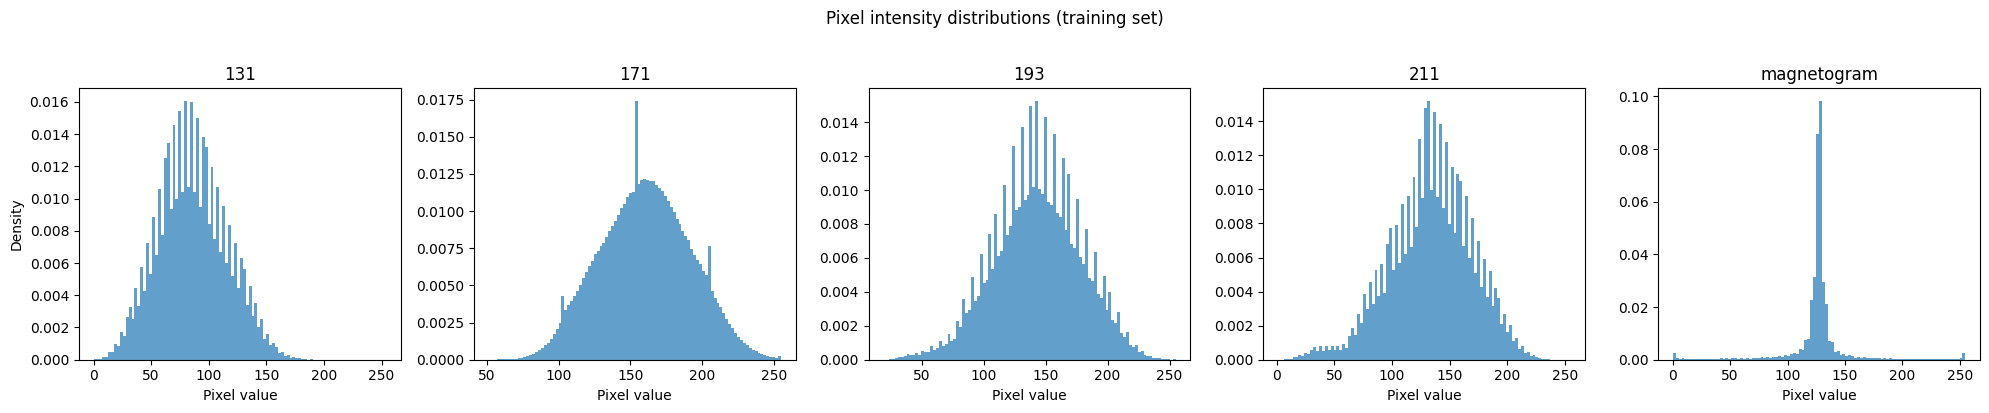

In [4]:
fig, axes = plt.subplots(1, len(channels), figsize=(4 * len(channels), 4))

SAMPLE_LIMIT = 50  # images per channel

for ax, ch in zip(axes, channels):
    pixels = []
    count = 0
    for _, row in train_df.iterrows():
        if count >= SAMPLE_LIMIT:
            break
        sid = str(row['id'])
        sdir = _sample_dir(train_split_root, sid)
        if sdir is None:
            continue
        matches = sorted(glob.glob(os.path.join(sdir, f'*__{ch}.jpg')))
        if matches:
            img = np.array(Image.open(matches[0]).convert('L'), dtype=np.float32)
            pixels.append(img.ravel())
            count += 1
    if pixels:
        all_px = np.concatenate(pixels)
        ax.hist(all_px, bins=100, density=True, alpha=0.7)
        ax.set_title(ch)
        ax.set_xlabel('Pixel value')

axes[0].set_ylabel('Density')
plt.suptitle('Pixel intensity distributions (training set)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Sample Image Grid

Display one sample across all 5 channels and up to 4 time-steps,
using timestamps discovered from file names.

In [ ]:
# Pick the first sample with a valid directory
sample_row = None
sample_dir = None
for _, row in train_df.iterrows():
    sid = str(row['id'])
    d = _sample_dir(train_split_root, sid)
    if d is not None:
        sample_row = row
        sample_dir = d
        break

timestamps = _discover_timesteps(sample_dir)
print(f'Sample: {sample_row["id"]}  peak_flux={sample_row["peak_flux"]:.2e}')
print(f'Timestamps: {timestamps}')

n_ts = len(timestamps)
fig, axes = plt.subplots(n_ts, len(channels), figsize=(3 * len(channels), 3 * n_ts))
if n_ts == 1:
    axes = axes[np.newaxis, :]  # ensure 2-D

for t_idx, ts_str in enumerate(timestamps):
    for ch_idx, ch in enumerate(channels):
        ax = axes[t_idx, ch_idx]
        img_path = os.path.join(sample_dir, f'{ts_str}__{ch}.jpg')
        if os.path.isfile(img_path):
            img = Image.open(img_path).convert('L')
            ax.imshow(np.array(img), cmap='hot')
        ax.set_title(f't{t_idx+1} / {ch}', fontsize=8)
        ax.axis('off')

plt.suptitle(f'Sample {sample_row["id"]} — peak_flux={sample_row["peak_flux"]:.2e}', y=1.01)
plt.tight_layout()
plt.show()

## 6. OMNI2 Time-Series Overview

In [ ]:
from solar_storm_forecast.dataset import load_omni2

omni = load_omni2(cfg)
print(f'OMNI2 shape: {omni.shape}')
print(f'Date range:  {omni.index.min()} — {omni.index.max()}')
print(f'\nMissing fraction per column (%):')
print((omni.isna().sum() / len(omni) * 100).round(2))

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)

for ax, col in zip(axes.ravel(), omni.columns):
    ax.plot(omni.index, omni[col], linewidth=0.3, alpha=0.8)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Date')
axes[-1, 1].set_xlabel('Date')
plt.suptitle('OMNI2 Features Over Time', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Dst Distribution & Storm Identification

In [ ]:
dst = omni['Dst'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dst, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(-50, color='red', ls='--', label='Storm threshold (-50 nT)')
axes[0].set_xlabel('Dst (nT)')
axes[0].set_ylabel('Count')
axes[0].set_title('Dst Distribution')
axes[0].legend()

axes[1].hist(dst[dst < -50], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1].set_xlabel('Dst (nT)')
axes[1].set_title('Storm events (Dst < -50 nT)')

plt.tight_layout()
plt.show()

n_storm = (dst < -50).sum()
print(f'Storm hours (Dst < -50): {n_storm} / {len(dst)} ({100*n_storm/len(dst):.2f}%)')

## 8. Correlation Between OMNI2 Features

In [ ]:
corr = omni.corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('OMNI2 Feature Correlation Matrix')
plt.tight_layout()
plt.show()